# Swiss Blue-Chip Stock Return Analysis
## Confidence Intervals, Statistical Testing & Market Scenarios

**Scientific Programming – Project Work FS2026**

---

### Research Question
Are the mean daily returns of major Swiss stocks (UBS, Nestlé, Novartis) significantly different from zero, and how do confidence interval widths vary across tickers, sample sizes, and market regimes?

### Objectives
1. Collect real-world stock data for multiple tickers via Yahoo Finance API
2. Compute confidence intervals for mean daily returns
3. Perform hypothesis testing (t-test with p-value) and correlation analysis
4. Compare real data against synthetic market scenarios
5. Store results in an SQLite database
6. Generate LLM-powered summaries of statistical results

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import sqlite3

from analysis import (
    ticker, TICKERS, log, make_reliability_table, summarize_returns_for_ci,
    plot_reliability_table, build_ci_table, plot_mean_se_and_ci,
    plot_ci_widths, rolling_ci_analysis, plot_rolling_ci_all,
    t_confidence_interval, MeanCI
)
from data_loader import DataLoader, prepare_data
from scenarios import generate_scenario, plot_scenarios_overview_one_image
from database import (
    get_connection, init_db, store_prices, store_ci_results,
    query_prices, query_ci_results, query_avg_return_by_ticker
)

sns.set_context("talk")
plt.rcParams.update({"figure.dpi": 120})

print(f"Analysing tickers: {TICKERS}")

Analysing tickers: ['UBS', 'NESN.SW', 'NOVN.SW']


/Users/tylerjordanstorz/PycharmProjects/ScientificProgramming/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Data Collection (Web API)
Using `yfinance` to fetch real-world stock data from Yahoo Finance for multiple Swiss blue-chip stocks.

In [2]:
loader = DataLoader(lookback_days=180)
raw_data = loader.fetch_all()

for sym, df in raw_data.items():
    print(f"{sym}: {df.shape[0]} rows, columns: {list(df.columns)[:5]}")

22:39:23 | INFO | Downloading UBS (~180 days) from Yahoo Finance...


22:39:24 | INFO | Downloading NESN.SW (~180 days) from Yahoo Finance...


22:39:24 | INFO | Downloading NOVN.SW (~180 days) from Yahoo Finance...


UBS: 180 rows, columns: [('Close', 'UBS'), ('High', 'UBS'), ('Low', 'UBS'), ('Open', 'UBS'), ('Volume', 'UBS')]
NESN.SW: 180 rows, columns: [('Close', 'NESN.SW'), ('High', 'NESN.SW'), ('Low', 'NESN.SW'), ('Open', 'NESN.SW'), ('Volume', 'NESN.SW')]
NOVN.SW: 180 rows, columns: [('Close', 'NOVN.SW'), ('High', 'NOVN.SW'), ('Low', 'NOVN.SW'), ('Open', 'NOVN.SW'), ('Volume', 'NOVN.SW')]


## 3. Data Preparation
- Column name cleaning with **regular expressions**
- Forward-filling missing values
- Computing daily returns

**Data structures used**: lists, dictionaries, sets, tuples, pandas DataFrames

In [3]:
prepared = {sym: prepare_data(df, n_trading_days=None) for sym, df in raw_data.items()}

for sym, df in prepared.items():
    print(f"\n{sym}: {len(df)} trading days")
    display(df.describe())

# Python built-in data structures
ticker_set = set(prepared.keys())                    # set
ticker_list = list(prepared.keys())                  # list
first_prices = tuple(df["Price"].iloc[0] for df in prepared.values())  # tuple
summary_dict = {                                     # dictionary
    sym: {
        "mean_return": df["Return"].mean(),
        "std_return": df["Return"].std(),
        "min_price": df["Price"].min(),
        "max_price": df["Price"].max(),
    }
    for sym, df in prepared.items()
}

print(f"\nTicker set: {ticker_set}")
print(f"First prices (tuple): {first_prices}")
for sym, s in summary_dict.items():
    print(f"  {sym}: mean={s['mean_return']:.6f}, std={s['std_return']:.6f}")

22:39:24 | INFO | Preparing data (cleaning + feature engineering)...


22:39:24 | INFO | Prepared full return series with 179 rows; last index=2026-05-01 00:00:00


22:39:24 | INFO | Preparing data (cleaning + feature engineering)...


22:39:24 | INFO | Prepared full return series with 179 rows; last index=2026-04-30 00:00:00


22:39:24 | INFO | Preparing data (cleaning + feature engineering)...


...


NESN.SW: 179 trading days


,Price,Return
count,179.000000,179.000000
mean,74.457293,0.000862
std,3.155385,0.013740
min,68.214630,-0.035502
25%,71.976044,-0.006740
50%,75.180206,-0.000754
75%,76.582932,0.006414
max,81.502068,0.092999



NOVN.SW: 179 trading days


,Price,Return
count,179.000000,179.000000
mean,108.047984,0.001275
std,9.713034,0.011666
min,93.728073,-0.041586
25%,99.832336,-0.004262
50%,104.306213,0.001961
75%,117.149998,0.007743
max,126.646446,0.038953



Ticker set: {'NESN.SW', 'NOVN.SW', 'UBS'}
First prices (tuple): (np.float64(38.91607666015625), np.float64(69.35794830322266), np.float64(94.64031219482422))
  UBS: mean=0.000790, std=0.016500
  NESN.SW: mean=0.000862, std=0.013740
  NOVN.SW: mean=0.001275, std=0.011666


## 4. Data Exploration
Tables and visualisations for exploratory analysis.

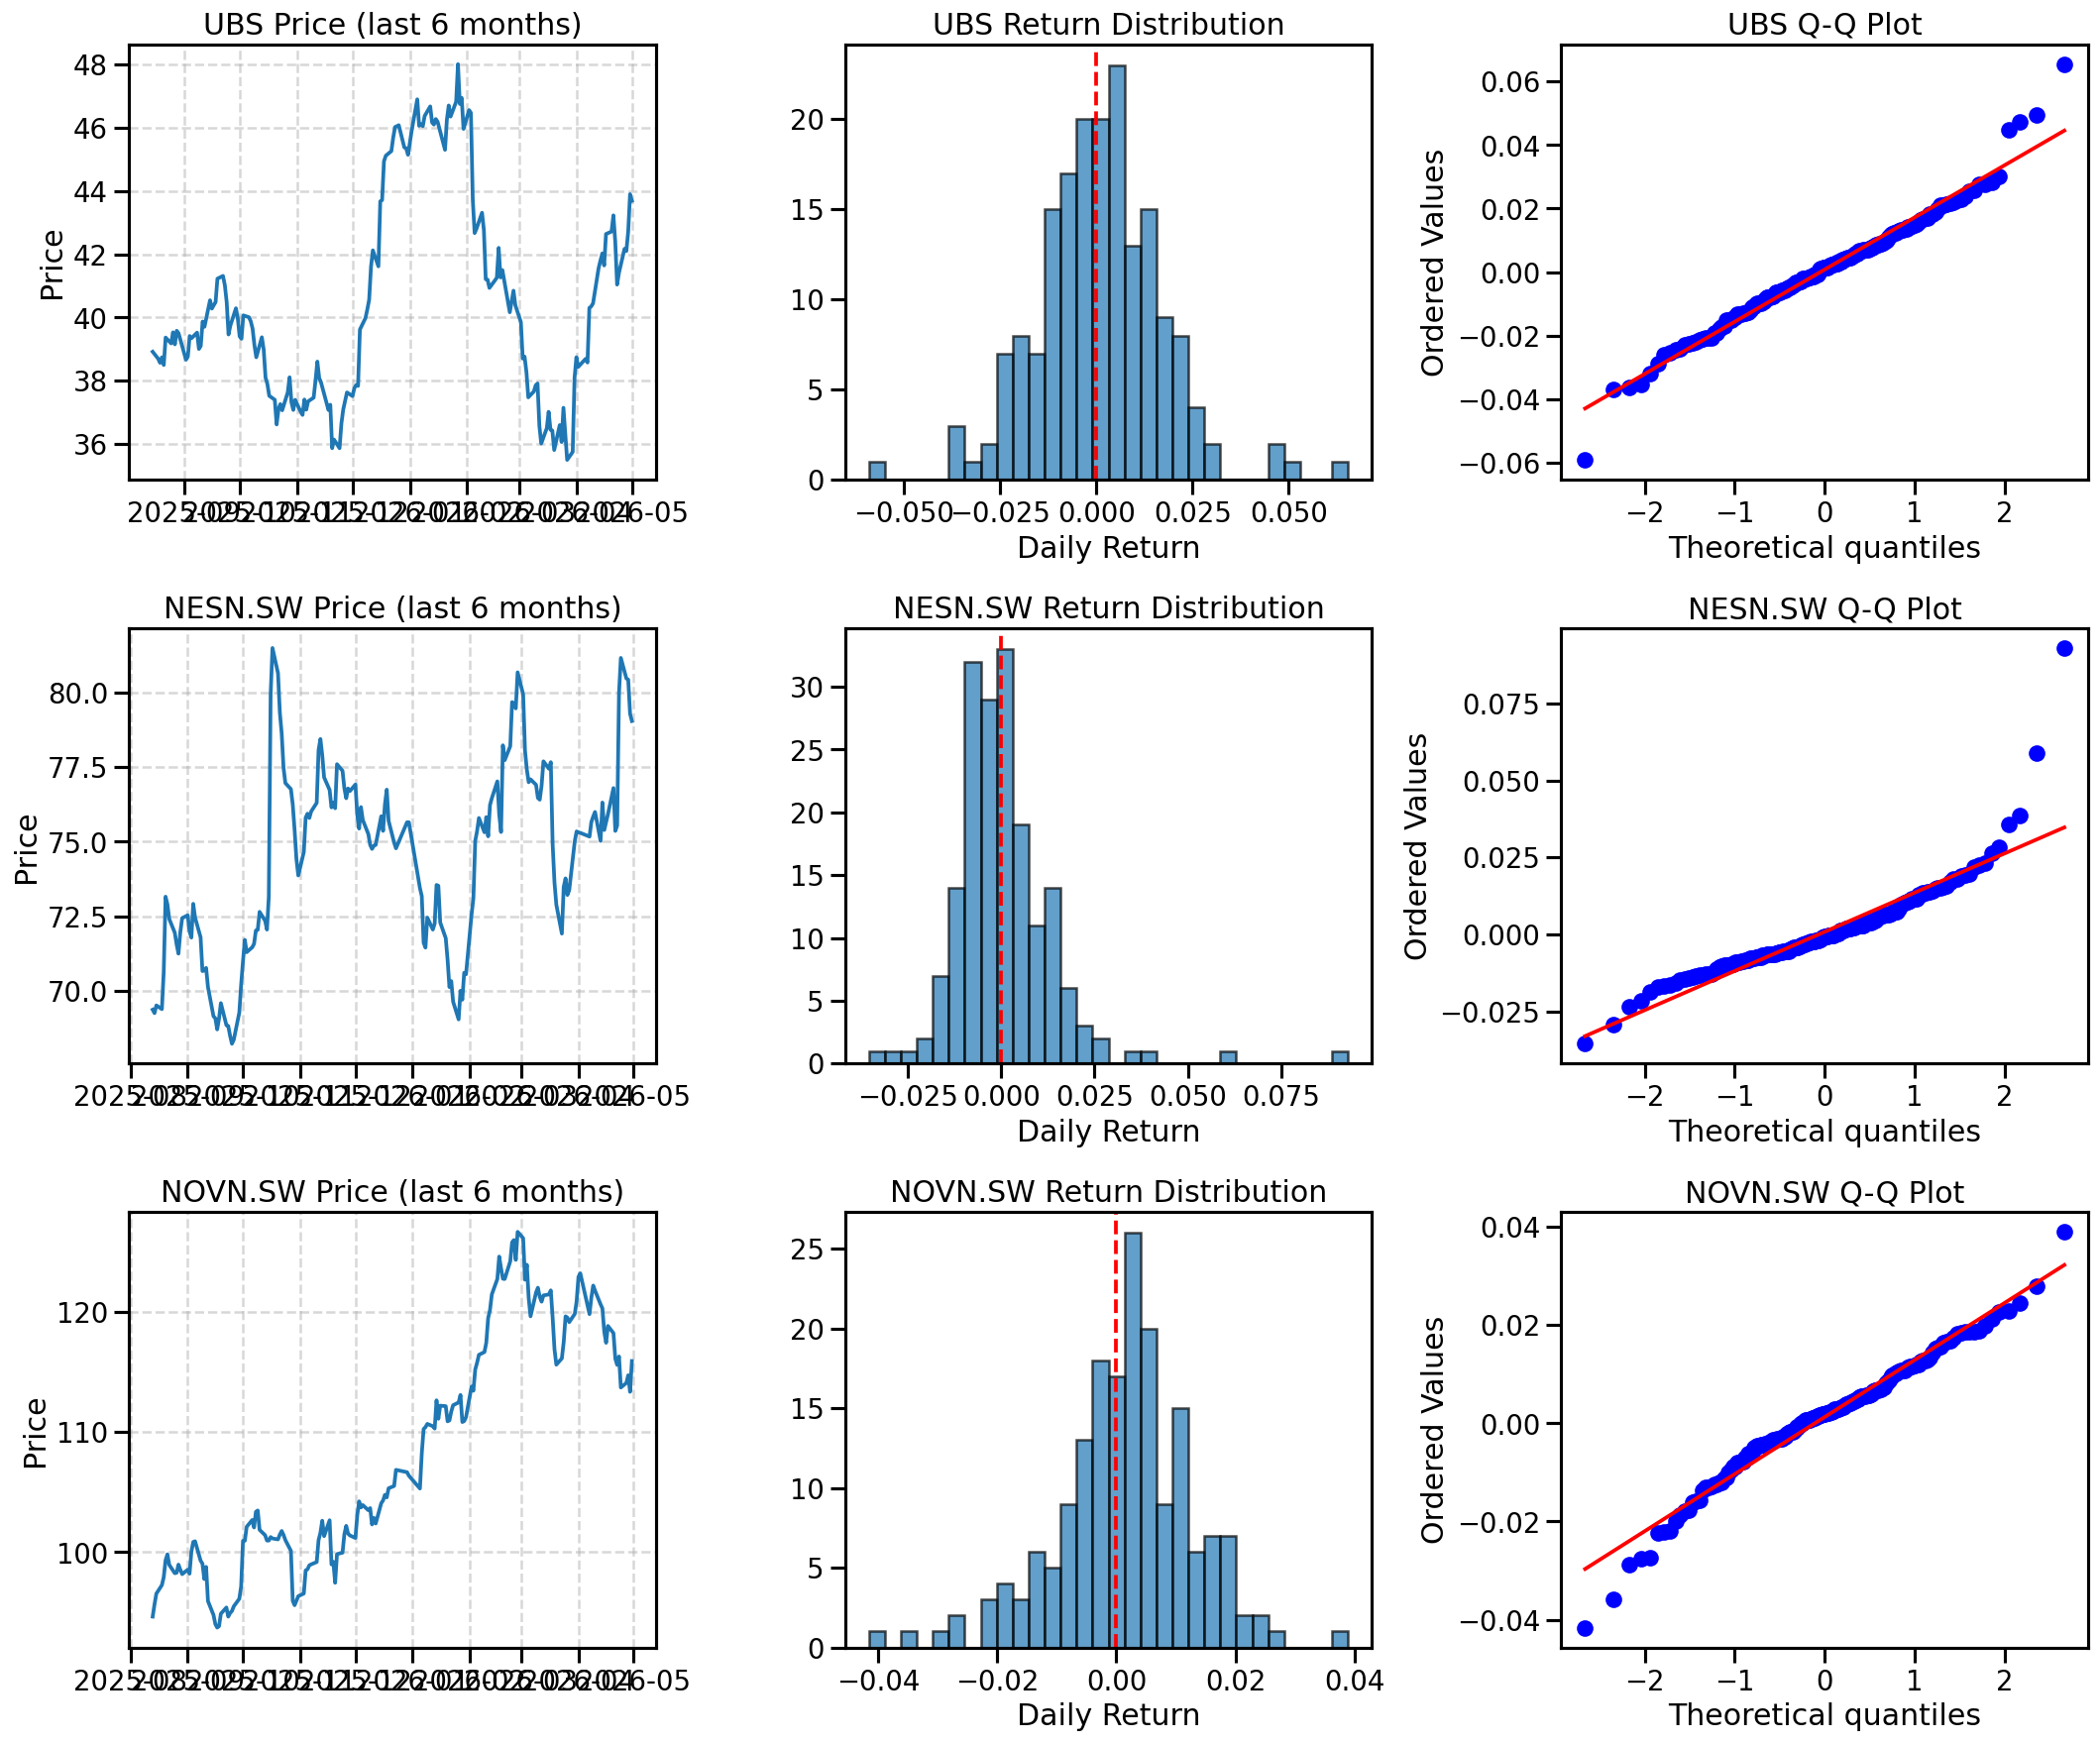

In [4]:
fig, axes = plt.subplots(len(TICKERS), 3, figsize=(18, 5 * len(TICKERS)))

for i, sym in enumerate(TICKERS):
    df = prepared[sym]
    axes[i, 0].plot(df.index, df["Price"])
    axes[i, 0].set_title(f"{sym} Price (last 6 months)")
    axes[i, 0].set_ylabel("Price")
    axes[i, 0].grid(True, linestyle="--", alpha=0.5)

    axes[i, 1].hist(df["Return"], bins=30, edgecolor="black", alpha=0.7)
    axes[i, 1].axvline(0, color="red", linestyle="--")
    axes[i, 1].set_title(f"{sym} Return Distribution")
    axes[i, 1].set_xlabel("Daily Return")

    stats.probplot(df["Return"].dropna(), dist="norm", plot=axes[i, 2])
    axes[i, 2].set_title(f"{sym} Q-Q Plot")

plt.tight_layout()
plt.show()

## 5. Reliability Table (Critical t-values)

,Confidence Level,1 - α,t_{α/2}
0,80%,0.800,1.383
1,90%,0.900,1.833
2,95%,0.950,2.262
3,98%,0.980,2.821
4,99%,0.990,3.250
5,99%,0.998,4.297
6,99%,0.999,4.781


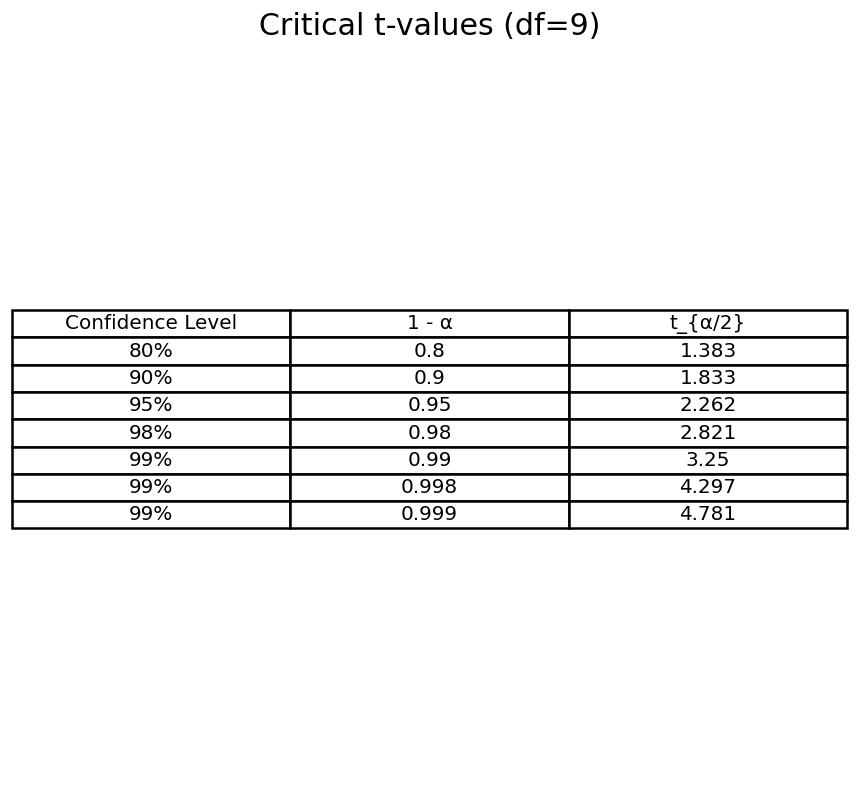

In [5]:
confs_table = [0.80, 0.90, 0.95, 0.98, 0.99, 0.998, 0.999]
reliability_tbl = make_reliability_table(confs_table)
display(reliability_tbl)
plot_reliability_table(reliability_tbl, title="Critical t-values (df=9)")

## 6. Confidence Intervals (10 Trading Days) — All Tickers

22:39:24 | INFO | Preparing data (cleaning + feature engineering)...


22:39:24 | INFO | Prepared 10 trading days; last index=2026-05-01 00:00:00



UBS: Mean=0.002581, SE=0.005678, df=9


,Confidence Level,df,Mean (ȳ),SE(ȳ),CI_lower,CI_upper,Width
0,90%,9,0.002581,0.005678,-0.007827,0.012989,0.020816
1,95%,9,0.002581,0.005678,-0.010263,0.015426,0.025688
2,99%,9,0.002581,0.005678,-0.015871,0.021033,0.036904


22:39:24 | INFO | MeanCI(mean=np.float64(0.0025813037340485347), se=np.float64(0.005677854831655651), df=9)


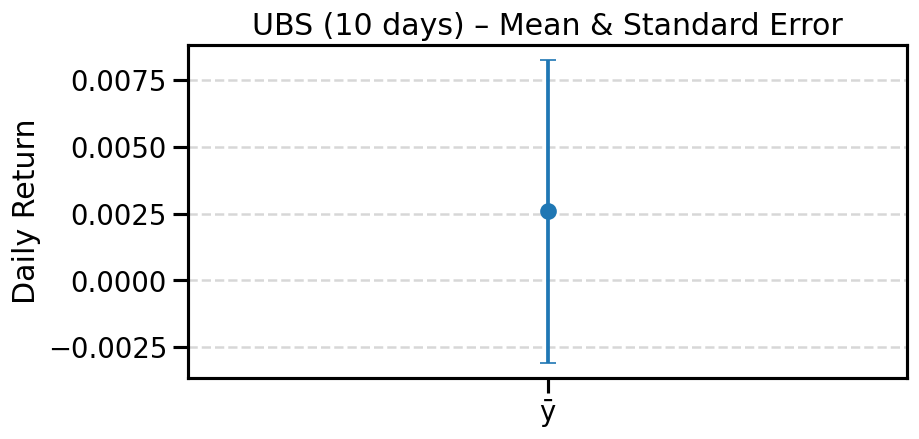

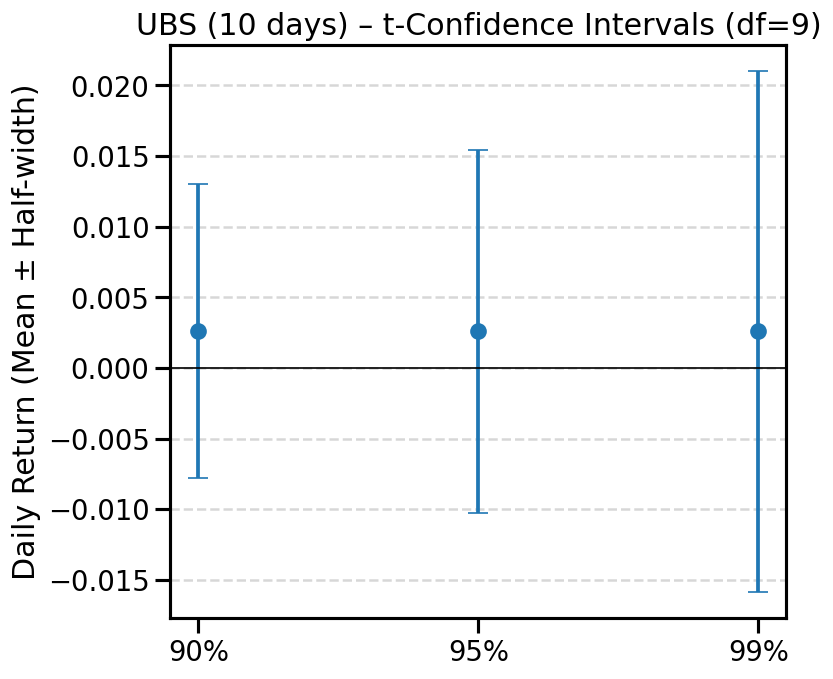

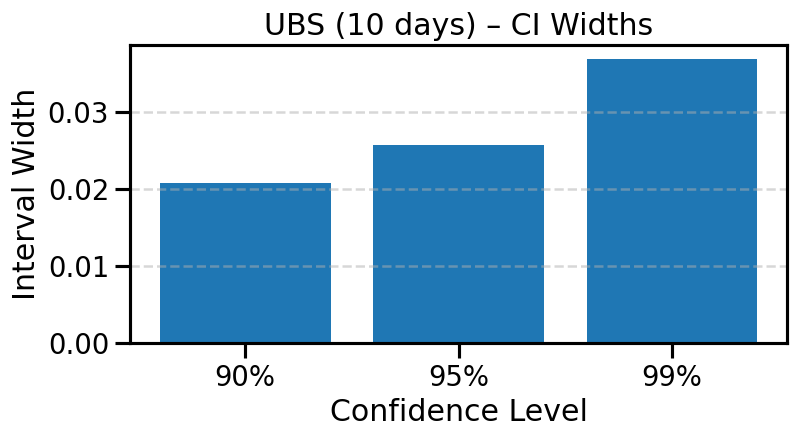

22:39:24 | INFO | Preparing data (cleaning + feature engineering)...


22:39:24 | INFO | Prepared 10 trading days; last index=2026-04-30 00:00:00



NESN.SW: Mean=0.004612, SE=0.006882, df=9


,Confidence Level,df,Mean (ȳ),SE(ȳ),CI_lower,CI_upper,Width
0,90%,9,0.004612,0.006882,-0.008003,0.017228,0.025231
1,95%,9,0.004612,0.006882,-0.010956,0.020181,0.031137
2,99%,9,0.004612,0.006882,-0.017753,0.026978,0.044732


22:39:24 | INFO | MeanCI(mean=np.float64(0.0046124510421865494), se=np.float64(0.006882119542728918), df=9)


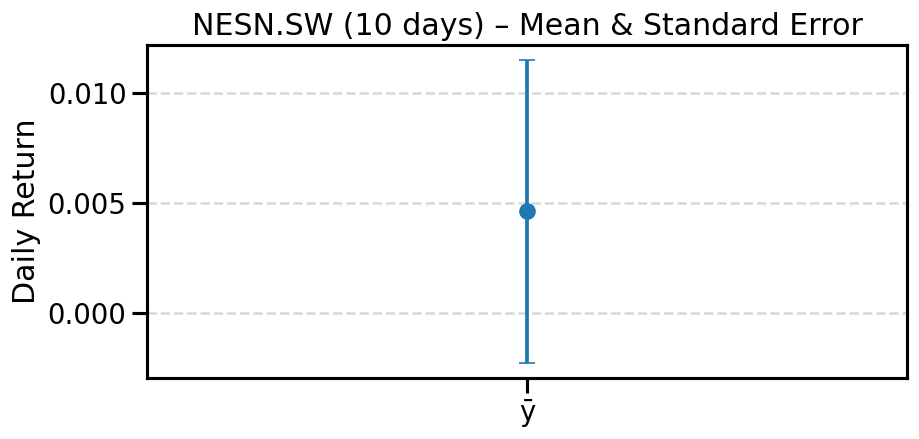

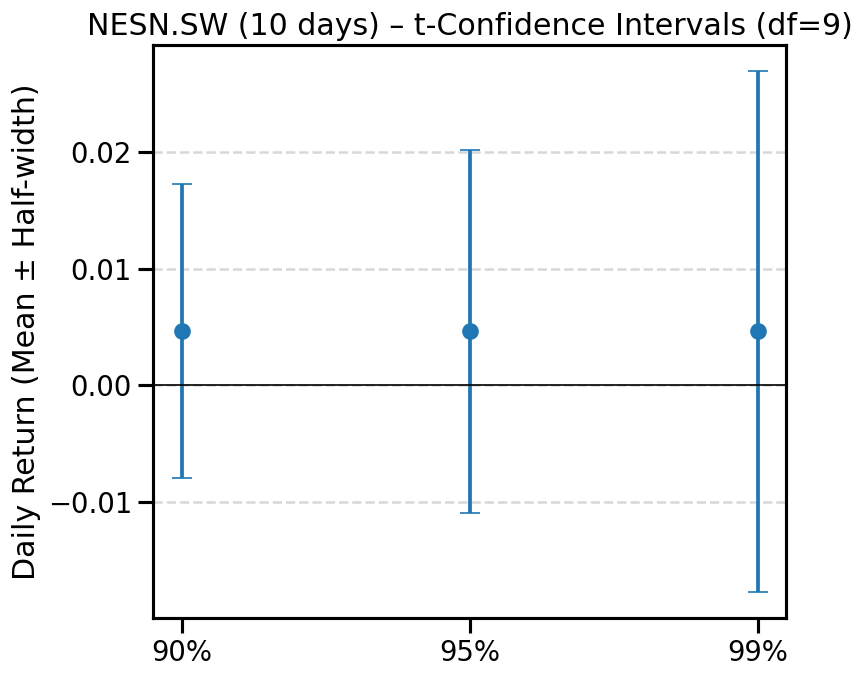

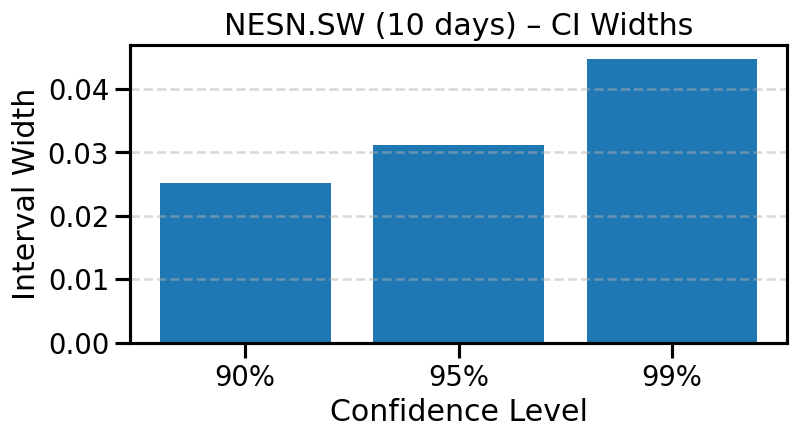

22:39:25 | INFO | Preparing data (cleaning + feature engineering)...


22:39:25 | INFO | Prepared 10 trading days; last index=2026-04-30 00:00:00



NOVN.SW: Mean=-0.001216, SE=0.004373, df=9


,Confidence Level,df,Mean (ȳ),SE(ȳ),CI_lower,CI_upper,Width
0,90%,9,-0.001216,0.004373,-0.009232,0.006800,0.016032
1,95%,9,-0.001216,0.004373,-0.011108,0.008676,0.019784
2,99%,9,-0.001216,0.004373,-0.015427,0.012995,0.028422


22:39:25 | INFO | MeanCI(mean=np.float64(-0.0012159744756169099), se=np.float64(0.0043729110734831095), df=9)


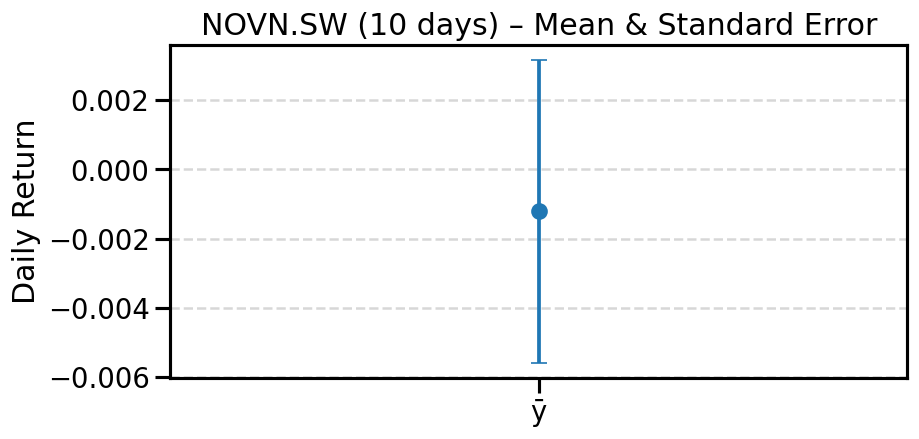

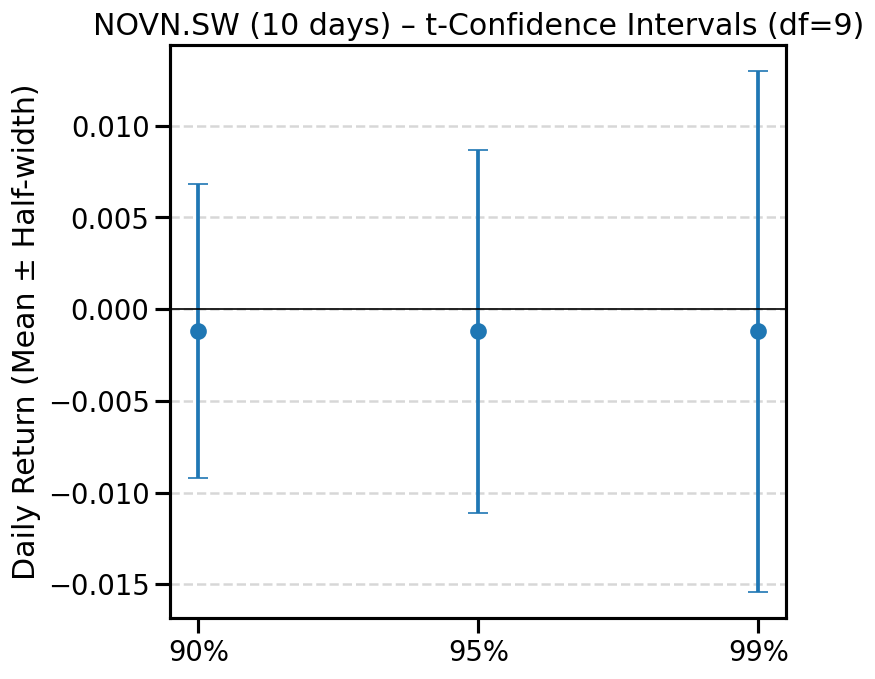

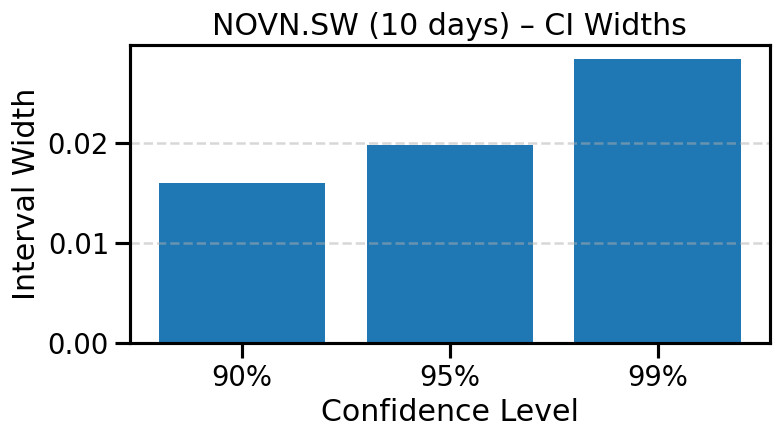

In [6]:
for sym in TICKERS:
    stock10 = prepare_data(raw_data[sym], n_trading_days=10)
    stats10 = summarize_returns_for_ci(stock10["Return"])
    print(f"\n{sym}: Mean={stats10.mean:.6f}, SE={stats10.se:.6f}, df={stats10.df}")

    ci_tbl = build_ci_table(stats10, [0.90, 0.95, 0.99])
    display(ci_tbl)
    plot_mean_se_and_ci(stats10, ci_tbl, title_prefix=f"{sym} (10 days)")
    plot_ci_widths(ci_tbl, title=f"{sym} (10 days) – CI Widths")

## 7. Statistical Hypothesis Tests (p-values)

**One-sample t-test**: Is the mean daily return significantly different from 0?
- $H_0$: $\mu = 0$
- $H_1$: $\mu \neq 0$
- Significance level: $\alpha = 0.05$

**Two-sample t-test**: Do UBS and Nestlé have the same mean return?

**Correlation analysis**: Autocorrelation of returns (predictability test)

ONE-SAMPLE T-TESTS (full dataset)
UBS       : t=+0.6407, p=0.522573  =>  fail to reject H0
NESN.SW   : t=+0.8392, p=0.402487  =>  fail to reject H0
NOVN.SW   : t=+1.4623, p=0.145432  =>  fail to reject H0

TWO-SAMPLE T-TEST: UBS vs Nestle
t-statistic: -0.0447
p-value:     0.964366
Result: No significant difference at alpha=0.05

RETURN AUTOCORRELATION (lag-1)
UBS       : r=+0.0209, p=0.782102  =>  not significant
NESN.SW   : r=+0.1964, p=0.008610  =>  significant
NOVN.SW   : r=+0.0389, p=0.605728  =>  not significant

CROSS-TICKER CORRELATION MATRIX


,UBS,NESN.SW,NOVN.SW
UBS,1.000000,-0.122394,0.087469
NESN.SW,-0.122394,1.000000,0.287053
NOVN.SW,0.087469,0.287053,1.000000


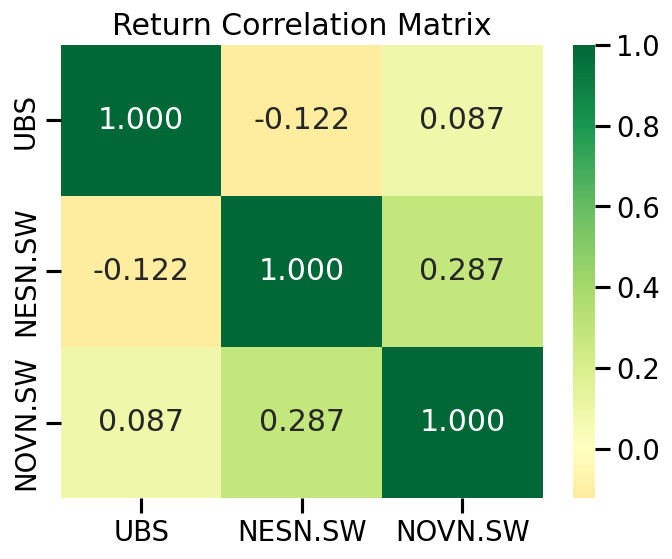

In [7]:
print("=" * 60)
print("ONE-SAMPLE T-TESTS (full dataset)")
print("=" * 60)

for sym in TICKERS:
    returns = prepared[sym]["Return"]
    t_stat, p_val = stats.ttest_1samp(returns, popmean=0)
    sig = "*** REJECT H0" if p_val < 0.05 else "fail to reject H0"
    print(f"{sym:10s}: t={t_stat:+.4f}, p={p_val:.6f}  =>  {sig}")

print()
print("=" * 60)
print("TWO-SAMPLE T-TEST: UBS vs Nestle")
print("=" * 60)

t2, p2 = stats.ttest_ind(prepared["UBS"]["Return"], prepared["NESN.SW"]["Return"])
print(f"t-statistic: {t2:.4f}")
print(f"p-value:     {p2:.6f}")
print(f"Result: {'Different means' if p2 < 0.05 else 'No significant difference'} at alpha=0.05")

print()
print("=" * 60)
print("RETURN AUTOCORRELATION (lag-1)")
print("=" * 60)

for sym in TICKERS:
    rets = prepared[sym]["Return"].dropna()
    corr, cp = stats.pearsonr(rets.iloc[1:].values, rets.shift(1).dropna().values)
    sig = "significant" if cp < 0.05 else "not significant"
    print(f"{sym:10s}: r={corr:+.4f}, p={cp:.6f}  =>  {sig}")

print()
print("=" * 60)
print("CROSS-TICKER CORRELATION MATRIX")
print("=" * 60)

ret_matrix = pd.DataFrame({sym: prepared[sym]["Return"] for sym in TICKERS}).dropna()
corr_matrix = ret_matrix.corr()
display(corr_matrix)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", center=0, ax=ax, fmt=".3f")
ax.set_title("Return Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Rolling CI Analysis

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0018855332817627746), 'Lower': np.float64(-0.0038911410224914834), 'Upper': np.float64(0.0076622075860170325), 'Width': np.float64(0.011553348608508516)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.001537983618051042), 'Lower': np.float64(-0.004282203361085167), 'Upper': np.float64(0.00735817059718725), 'Width': np.float64(0.011640373958272417)}, {'EndDate': Timestamp('2025-09-02 00:00:00'), 'Mean': np.float64(-8.27785838527495e-06), 'Lower': np.float64(-0.007103147223098332), 'Upper': np.float64(0.0070865915063277815), 'Width': np.float64(0.014189738729426114)}, {'EndDate': Timestamp('2025-09-03 00:00:00'), 'Mean': np.float64(0.0005713954380617392), 'Lower': np.float64(-0.006503357445106007), 'Upper': np.float64(0.007646148321229486), 'Width': np.float64(0.014149505766335493)}, {'EndDate': Timestamp('2025-09-04 00:00:00'), 'Mean': np.float64(0.0018014986672859278), 'Lower': np

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0018855332817627746), 'Lower': np.float64(-0.005243184715947811), 'Upper': np.float64(0.00901425127947336), 'Width': np.float64(0.014257435995421171)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.001537983618051042), 'Lower': np.float64(-0.005644431294566283), 'Upper': np.float64(0.008720398530668368), 'Width': np.float64(0.01436482982523465)}, {'EndDate': Timestamp('2025-09-02 00:00:00'), 'Mean': np.float64(-8.27785838527495e-06), 'Lower': np.float64(-0.00876371745351487), 'Upper': np.float64(0.00874716173674432), 'Width': np.float64(0.01751087919025919)}, {'EndDate': Timestamp('2025-09-03 00:00:00'), 'Mean': np.float64(0.0005713954380617392), 'Lower': np.float64(-0.008159219367493507), 'Upper': np.float64(0.009302010243616984), 'Width': np.float64(0.01746122961111049)}, {'EndDate': Timestamp('2025-09-04 00:00:00'), 'Mean': np.float64(0.0018014986672859278), 'Lower': np.float64


Rolling CI for UBS:


22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0018855332817627746), 'Lower': np.float64(-0.008355647788838867), 'Upper': np.float64(0.012126714352364416), 'Width': np.float64(0.020482362141203282)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.001537983618051042), 'Lower': np.float64(-0.008780338928573246), 'Upper': np.float64(0.011856306164675331), 'Width': np.float64(0.020636645093248578)}, {'EndDate': Timestamp('2025-09-02 00:00:00'), 'Mean': np.float64(-8.27785838527495e-06), 'Lower': np.float64(-0.012586421961607466), 'Upper': np.float64(0.012569866244836915), 'Width': np.float64(0.02515628820644438)}, {'EndDate': Timestamp('2025-09-03 00:00:00'), 'Mean': np.float64(0.0005713954380617392), 'Lower': np.float64(-0.011971085146817863), 'Upper': np.float64(0.01311387602294134), 'Width': np.float64(0.025084961169759203)}, {'EndDate': Timestamp('2025-09-04 00:00:00'), 'Mean': np.float64(0.0018014986672859278), 'Lower': np.flo

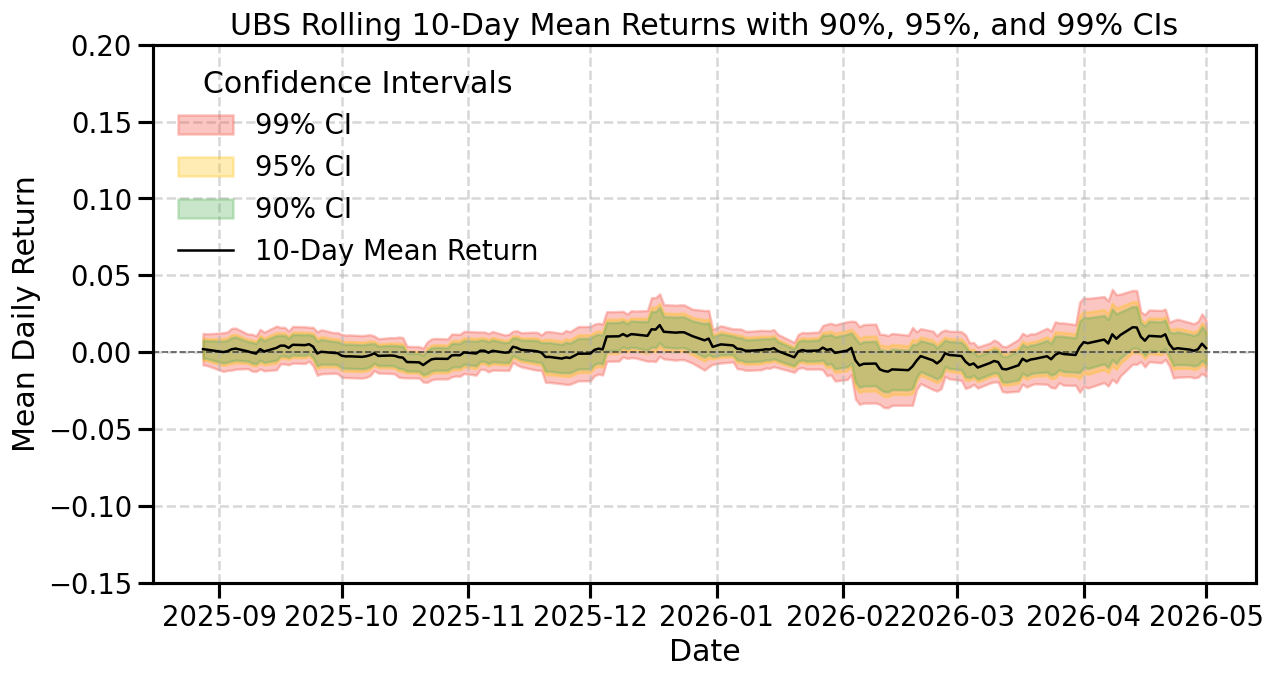


Rolling CI for NESN.SW:


22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.0038926562028907207), 'Lower': np.float64(-0.003943255612346692), 'Upper': np.float64(0.011728568018128134), 'Width': np.float64(0.015671823630474827)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.0027655011311077836), 'Lower': np.float64(-0.005176588418088026), 'Upper': np.float64(0.010707590680303594), 'Width': np.float64(0.01588417909839162)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.003943202447226723), 'Lower': np.float64(-0.004047010307980352), 'Upper': np.float64(0.011933415202433798), 'Width': np.float64(0.01598042551041415)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.004222777034715919), 'Lower': np.float64(-0.003781286166865406), 'Upper': np.float64(0.012226840236297245), 'Width': np.float64(0.01600812640316265)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.004535117782200271), 'Lower': np.float6

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.0038926562028907207), 'Lower': np.float64(-0.005777268505278755), 'Upper': np.float64(0.013562580911060197), 'Width': np.float64(0.019339849416338952)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.0027655011311077836), 'Lower': np.float64(-0.0070354524499320085), 'Upper': np.float64(0.012566454712147575), 'Width': np.float64(0.019601907162079584)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.003943202447226723), 'Lower': np.float64(-0.005917137685093517), 'Upper': np.float64(0.013803542579546964), 'Width': np.float64(0.01972068026464048)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.004222777034715919), 'Lower': np.float64(-0.005654655272295858), 'Upper': np.float64(0.014100209341727697), 'Width': np.float64(0.019754864614023555)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.004535117782200271), 'Lower': np.flo

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.0038926562028907207), 'Lower': np.float64(-0.009999245525758477), 'Upper': np.float64(0.017784557931539918), 'Width': np.float64(0.027783803457298396)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.0027655011311077836), 'Lower': np.float64(-0.011314637867268273), 'Upper': np.float64(0.016845640129483842), 'Width': np.float64(0.028160277996752116)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.003943202447226723), 'Lower': np.float64(-0.01022225181050129), 'Upper': np.float64(0.018108656704954734), 'Width': np.float64(0.028330908515456023)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.004222777034715919), 'Lower': np.float64(-0.009967231996529942), 'Upper': np.float64(0.01841278606596178), 'Width': np.float64(0.028380018062491724)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.004535117782200271), 'Lower': np.float

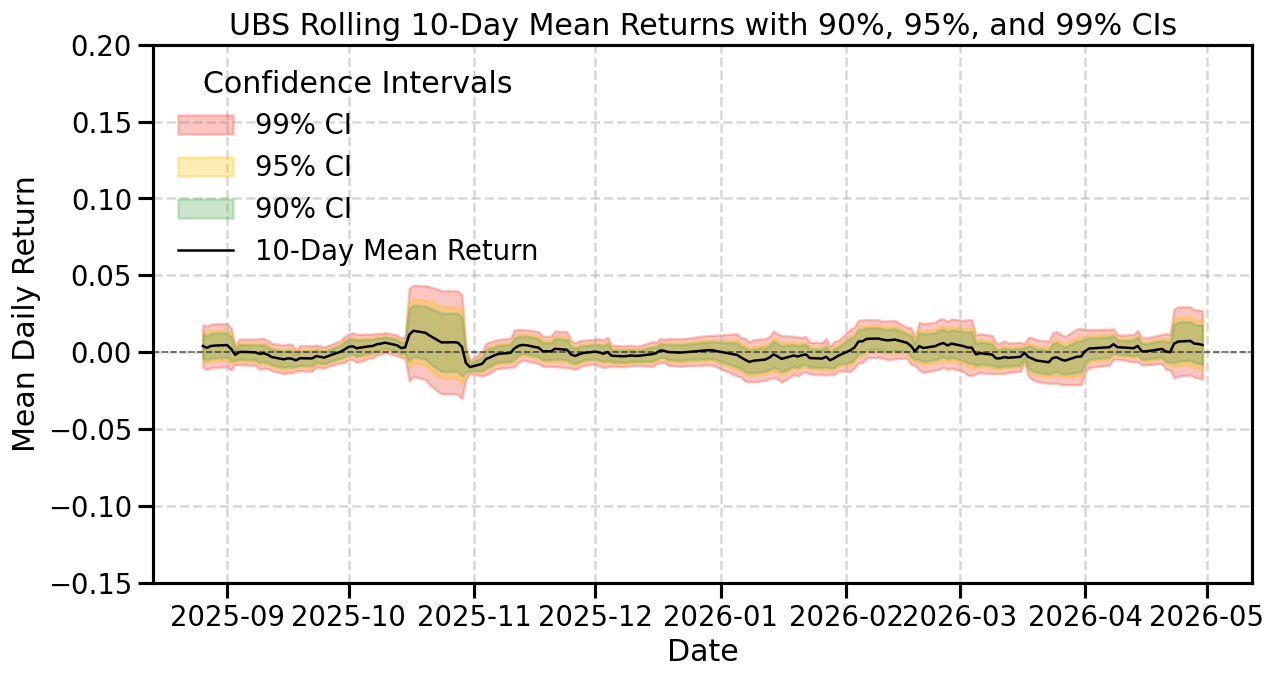

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.005156654287255202), 'Lower': np.float64(0.0005170915565935567), 'Upper': np.float64(0.009796217017916848), 'Width': np.float64(0.009279125461323291)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.004507284591491767), 'Lower': np.float64(0.00015496374776859806), 'Upper': np.float64(0.008859605435214937), 'Width': np.float64(0.008704641687446339)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0029991197911998667), 'Lower': np.float64(-0.001420854600680331), 'Upper': np.float64(0.007419094183080064), 'Width': np.float64(0.008839948783760395)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.0016915441688100774), 'Lower': np.float64(-0.002678418017970934), 'Upper': np.float64(0.006061506355591089), 'Width': np.float64(0.008739924373562023)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.001333433143307161), 'Lower': np.fl

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.005156654287255202), 'Lower': np.float64(-0.0005688085997933795), 'Upper': np.float64(0.010882117174303783), 'Width': np.float64(0.011450925774097162)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.004507284591491767), 'Lower': np.float64(-0.0008637067949553955), 'Upper': np.float64(0.00987827597793893), 'Width': np.float64(0.010741982772894326)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0029991197911998667), 'Lower': np.float64(-0.0024553596094496564), 'Upper': np.float64(0.00845359919184939), 'Width': np.float64(0.010908958801299046)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.0016915441688100774), 'Lower': np.float64(-0.003701217556959766), 'Upper': np.float64(0.007084305894579921), 'Width': np.float64(0.010785523451539688)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.001333433143307161), 'Lower': np.fl

22:39:25 | INFO | [{'EndDate': Timestamp('2025-08-26 00:00:00'), 'Mean': np.float64(0.005156654287255202), 'Lower': np.float64(-0.0030685977367560114), 'Upper': np.float64(0.013381906311266416), 'Width': np.float64(0.016450504048022428)}, {'EndDate': Timestamp('2025-08-27 00:00:00'), 'Mean': np.float64(0.004507284591491767), 'Lower': np.float64(-0.003208730452855941), 'Upper': np.float64(0.012223299635839475), 'Width': np.float64(0.015432030088695415)}, {'EndDate': Timestamp('2025-08-28 00:00:00'), 'Mean': np.float64(0.0029991197911998667), 'Lower': np.float64(-0.00483683489319896), 'Upper': np.float64(0.010835074475598692), 'Width': np.float64(0.015671909368797653)}, {'EndDate': Timestamp('2025-08-29 00:00:00'), 'Mean': np.float64(0.0016915441688100774), 'Lower': np.float64(-0.006055746342885844), 'Upper': np.float64(0.009438834680505999), 'Width': np.float64(0.015494581023391843)}, {'EndDate': Timestamp('2025-09-01 00:00:00'), 'Mean': np.float64(0.001333433143307161), 'Lower': np.flo


Rolling CI for NOVN.SW:


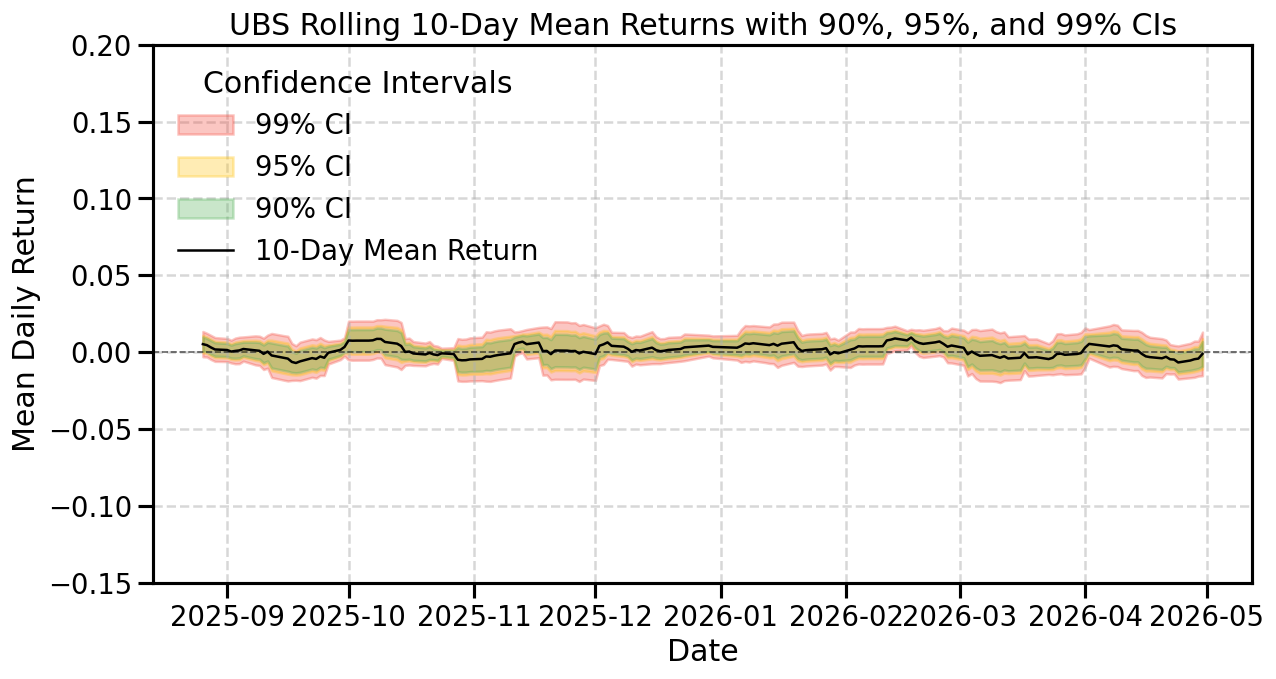

In [8]:
for sym in TICKERS:
    print(f"\nRolling CI for {sym}:")
    confs = [0.90, 0.95, 0.99]
    roll_dfs = {c: rolling_ci_analysis(prepared[sym], window=10, conf=c) for c in confs}
    plot_rolling_ci_all(roll_dfs, ystep=0.05, ylims=(-0.15, 0.20))

## 9. Synthetic Market Scenarios

22:39:25 | INFO | Preparing data (cleaning + feature engineering)...


22:39:25 | INFO | Prepared 60 trading days; last index=2026-05-01 00:00:00


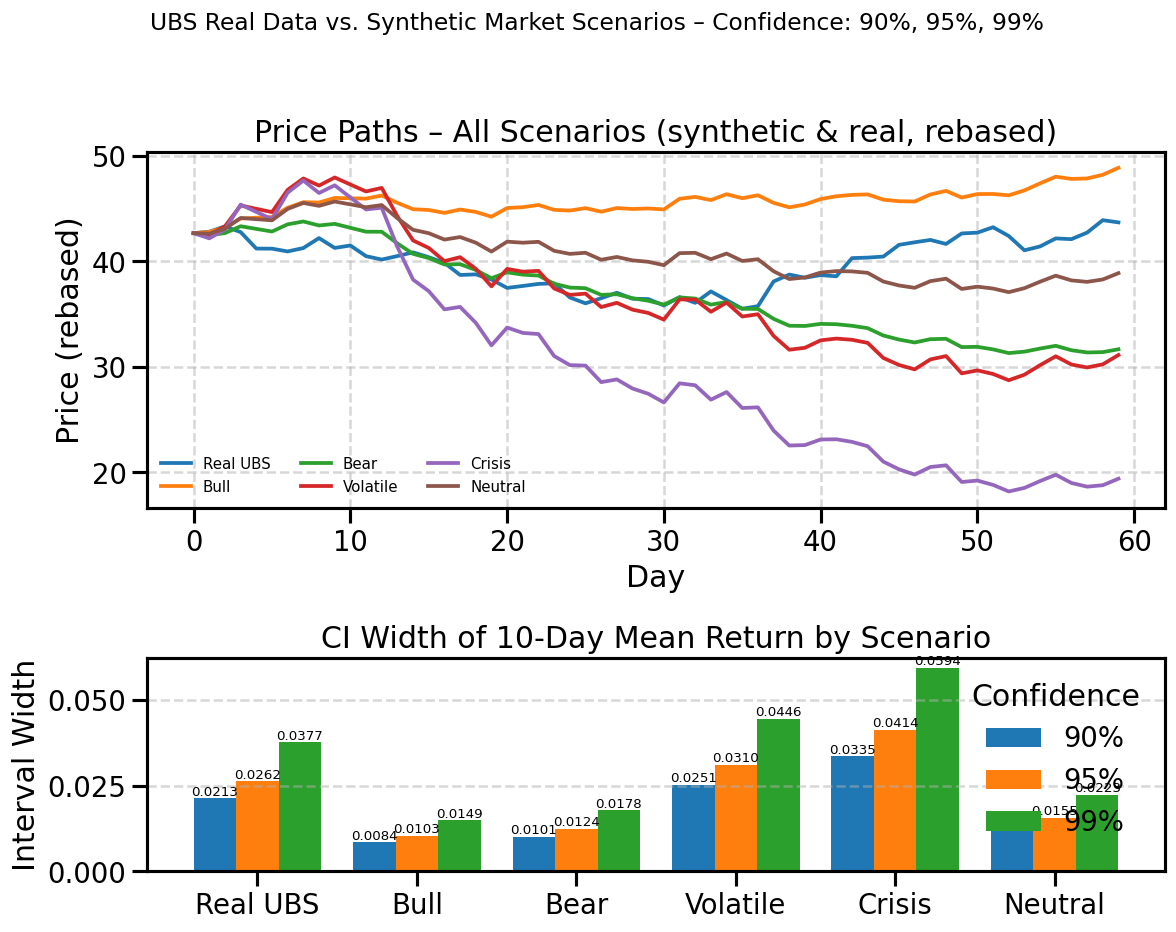

In [9]:
primary = TICKERS[0]
stocks_60 = prepare_data(raw_data[primary], n_trading_days=60)
base_price = float(stocks_60["Price"].iloc[0])

scenarios = {
    f"Real {primary}": stocks_60,
    "Bull": generate_scenario("bull", n_days=60, seed=42, base_price=base_price),
    "Bear": generate_scenario("bear", n_days=60, seed=42, base_price=base_price),
    "Volatile": generate_scenario("volatile", n_days=60, seed=42, base_price=base_price),
    "Crisis": generate_scenario("crisis", n_days=60, seed=42, base_price=base_price),
    "Neutral": generate_scenario("neutral", n_days=60, seed=42, base_price=base_price),
}

plot_scenarios_overview_one_image(
    scenarios, conf=[0.90, 0.95, 0.99], sample_n=10,
    title=f"{primary} Real Data vs. Synthetic Market Scenarios",
    rebase_to=base_price
)

## 10. SQLite Database Storage
Storing data and results in an SQLite database and querying them back with SQL.

In [10]:
conn = get_connection()
init_db(conn)

for sym in TICKERS:
    n = store_prices(prepared[sym], sym, conn)
    print(f"Stored {n} price rows for {sym}")

primary_10 = prepare_data(raw_data[TICKERS[0]], n_trading_days=10)
primary_stats = summarize_returns_for_ci(primary_10["Return"])
primary_ci = build_ci_table(primary_stats, [0.90, 0.95, 0.99])
store_ci_results(primary_ci, TICKERS[0],
                 window_start=str(primary_10.index.min().date()),
                 window_end=str(primary_10.index.max().date()),
                 conn=conn)
print("Stored CI results")

print("\n--- Average return by ticker (SQL aggregate query) ---")
display(query_avg_return_by_ticker(conn=conn))

print("\n--- Days with |return| > 3% (SQL filter query) ---")
extreme = pd.read_sql_query(
    "SELECT ticker, date, price, return_ FROM stock_prices "
    "WHERE ABS(return_) > 0.03 ORDER BY ABS(return_) DESC",
    conn
)
display(extreme if len(extreme) > 0 else "No extreme days found")

conn.close()

22:39:25 | INFO | Preparing data (cleaning + feature engineering)...


22:39:25 | INFO | Prepared 10 trading days; last index=2026-05-01 00:00:00


Stored 179 price rows for UBS
Stored 179 price rows for NESN.SW
Stored 179 price rows for NOVN.SW
Stored CI results

--- Average return by ticker (SQL aggregate query) ---


,ticker,n_days,avg_return,first_date,last_date
0,NOVN.SW,179,0.001275,2025-08-13,2026-04-30
1,NESN.SW,179,0.000862,2025-08-13,2026-04-30
2,UBS,179,0.000790,2025-08-15,2026-05-01



--- Days with |return| > 3% (SQL filter query) ---


,ticker,date,price,return_
0,NESN.SW,2025-10-16,79.945625,0.092999
1,UBS,2026-03-31,38.087456,0.065449
2,UBS,2026-02-04,43.722095,-0.059157
3,NESN.SW,2026-04-23,79.989998,0.058909
4,UBS,2025-12-16,43.673355,0.049426
5,UBS,2025-12-05,39.617970,0.047153
6,UBS,2026-04-08,40.300369,0.044731
7,NOVN.SW,2025-10-28,95.950455,-0.041586
8,NOVN.SW,2025-10-01,100.948372,0.038953
9,NESN.SW,2026-02-19,78.235451,0.038648


## 11. LLM-Powered Analysis Summary
Using OpenAI API to generate natural-language interpretations of statistical results.

> **Note:** Set `OPENAI_API_KEY` environment variable before running this cell.
> If not available, this cell will show a fallback message.

In [11]:
try:
    from llm_summary import summarise_statistics, compare_tickers_summary

    # Single-ticker summary
    primary_returns = prepared[TICKERS[0]]["Return"]
    t_stat, p_val = stats.ttest_1samp(primary_returns, popmean=0)
    primary_10 = prepare_data(raw_data[TICKERS[0]], n_trading_days=10)
    primary_stats = summarize_returns_for_ci(primary_10["Return"])
    primary_ci = build_ci_table(primary_stats, [0.90, 0.95, 0.99])

    summary = summarise_statistics(
        ticker=TICKERS[0],
        descriptive_stats=prepared[TICKERS[0]].describe(),
        t_test_result=(t_stat, p_val),
        ci_table=primary_ci,
    )
    print("=== LLM Summary (single ticker) ===")
    print(summary)

    # Multi-ticker comparison
    ticker_stats = {}
    for sym in TICKERS:
        r = prepared[sym]["Return"]
        ts, pv = stats.ttest_1samp(r, popmean=0)
        ticker_stats[sym] = {"mean": r.mean(), "std": r.std(), "t_stat": ts, "p_value": pv}

    comparison = compare_tickers_summary(ticker_stats)
    print("\n=== LLM Comparison (all tickers) ===")
    print(comparison)

except RuntimeError as e:
    print(f"LLM unavailable: {e}")
    print("Set OPENAI_API_KEY to enable LLM summaries.")

22:39:25 | INFO | Preparing data (cleaning + feature engineering)...


22:39:25 | INFO | Prepared 10 trading days; last index=2026-05-01 00:00:00


22:39:35 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== LLM Summary (single ticker) ===
### Summary of Statistical Analysis for UBS

1. **Return Distribution**: The stock ticker "UBS" has a mean return of approximately 0.079% with a standard deviation of 1.65%. The returns range from a minimum of -5.92% to a maximum of 6.54%. The 25th percentile return is -0.88%, the median is 0.15%, and the 75th percentile is 0.96%. This indicates a relatively low average return with some variability, suggesting that while most returns are clustered around zero, there are instances of both negative and positive returns.

2. **Hypothesis Test Interpretation**: The one-sample t-test, which tests the null hypothesis that the mean return is zero, yielded a t-statistic of 0.6407 and a p-value of 0.522573. Since the p-value is significantly higher than common significance levels (0.05, 0.01), we fail to reject the null hypothesis. This implies that there is no statistically significant evidence to suggest that the average return of UBS is different from zero

22:39:35 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


22:39:35 | INFO | Retrying request to /chat/completions in 0.380566 seconds


22:39:39 | INFO | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



=== LLM Comparison (all tickers) ===
Among the Swiss blue-chip stocks analyzed, Novartis (NOVN.SW) exhibits the highest average return at 0.001275, followed by Nestlé (NESN.SW) at 0.000862, and UBS at 0.000790. In terms of volatility, UBS is the most volatile with a standard deviation of 0.016500, while Novartis is the least volatile at 0.011666, indicating a more stable return profile.

None of the stocks show statistically significant returns, as all p-values exceed the 0.05 threshold: UBS (p = 0.522573), Nestlé (p = 0.402487), and Novartis (p = 0.145432). This suggests that the observed average returns may not be reliably different from zero.

From an investment perspective, while Novartis offers the highest average return and lower volatility, the lack of statistical significance in returns across all stocks indicates caution. Investors may want to consider additional factors such as market conditions, company fundamentals, and diversification strategies before making investment d

## 12. Conclusions

### Key Findings
1. **Confidence intervals** widen with increasing confidence level
2. **Rolling analysis** reveals time-varying uncertainty in return estimates
3. **Hypothesis tests** show whether Swiss blue-chip returns differ from zero
4. **Cross-ticker correlation** reveals co-movement between UBS, Nestlé, and Novartis
5. **Scenario comparison**: Volatile/crisis scenarios produce wider CIs

### Methods Used
- Real-world data collection (yfinance Web API) — multiple tickers
- Data preparation with regex, pandas
- Python data structures: lists, dicts, sets, tuples, DataFrames
- Conditional statements, loops, procedural & OOP programming
- Statistical visualisations (matplotlib, seaborn)
- Statistical analysis with p-values (scipy): t-tests, correlation
- SQLite database with SQL queries
- LLM integration (OpenAI API) for automated analysis summaries
- Streamlit web application (`streamlit run app.py`)